# 14장 실습 — 평가: 성공률 하나로는 아무것도 모른다

**대응 이론** 14장 「무엇을 어떻게 재는가」 · **실행 등급 A** (CPU / Colab 무료 티어, 전체 약 2분)

"새 정책이 80%, 기존이 70% 였습니다." 이 문장은 VLA 논문과 사내 보고서 어디에나 있다. 그리고 대개 **아무것도 증명하지 않는다.**

로봇 평가는 비싸다. 한 번 돌리는 데 사람이 붙어서 물건을 제자리에 놓아야 하고, 한 시간에 스무 번이면 많이 한 것이다. 그래서 표본이 작고, 작은 표본에서 성공률 두 개를 비교하는 일은 우리 직관이 아주 나쁜 영역이다.

이 노트북에는 모델이 없다. 숫자만 있다. 그런데 이 장의 내용을 모르면 앞의 열세 장이 만든 모델의 좋고 나쁨을 판단할 수 없다.

1. 성공률 하나는 얼마나 불확실한가
2. 신뢰구간이 겹치면 차이가 없는 것인가
3. 몇 번 돌려야 하는가
4. 같은 조건에서 겨루게 하면
5. 성공/실패 대신 진행도를 재면

In [1]:
%matplotlib inline
import os, math
import numpy as np
from math import sqrt, erf, comb
from statistics import NormalDist
import matplotlib.pyplot as plt
import koreanize_matplotlib

np.random.seed(0)
RED, GREY, PINK = "#e32c24", "#c8c8c8", "#f6c9c6"
rng = np.random.default_rng(0)
print("준비 완료")

준비 완료


## 1. 성공률 하나는 얼마나 불확실한가

20번 돌려서 15번 성공했다. 이 정책의 성공률은 75% 인가?

75% 는 **추정값**이고, 참값이 얼마인지는 구간으로만 말할 수 있다. 성공/실패 같은 이항 데이터에는 Wilson 구간을 쓴다. 정규 근사(Wald)보다 표본이 작을 때 훨씬 정직하다.

<!-- LaTeX: \text{Wilson} = \frac{\hat p + \frac{z^2}{2n}}{1 + \frac{z^2}{n}} \pm \frac{z}{1+\frac{z^2}{n}}\sqrt{\frac{\hat p(1-\hat p)}{n} + \frac{z^2}{4n^2}} -->

참 성공률 75% 인 정책을 n번 돌렸을 때의 95% 신뢰구간
     n                  구간       폭
----------------------------------
    10   [0.49, 0.94]        0.45
    20   [0.53, 0.89]        0.36
    50   [0.63, 0.86]        0.23
   100   [0.66, 0.82]        0.17
   200   [0.69, 0.80]        0.12
   500   [0.71, 0.79]        0.08


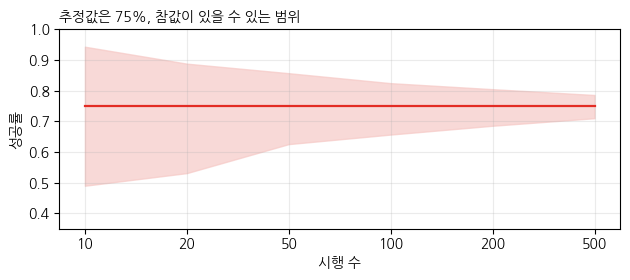

In [2]:
def wilson(k, n, z=1.96):
    if n == 0: return (0.0, 1.0)
    p = k / n; d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return c - h, c + h

ns = [10, 20, 50, 100, 200, 500]
los, his = [], []
print("참 성공률 75% 인 정책을 n번 돌렸을 때의 95% 신뢰구간")
print(f"{'n':>6}{'구간':>20}{'폭':>8}")
print("-" * 34)
for n in ns:
    lo, hi = wilson(round(.75 * n), n); los.append(lo); his.append(hi)
    print(f"{n:>6}   [{lo:.2f}, {hi:.2f}]{hi-lo:>12.2f}")

fig, ax = plt.subplots(figsize=(6.4, 2.9))
ax.fill_between(range(len(ns)), los, his, color=PINK, alpha=.7)
ax.plot(range(len(ns)), [.75] * len(ns), color=RED, lw=1.6)
ax.set_xticks(range(len(ns))); ax.set_xticklabels(ns)
ax.set_xlabel("시행 수"); ax.set_ylabel("성공률"); ax.set_ylim(.35, 1.0)
ax.grid(alpha=.25); ax.set_title("추정값은 75%, 참값이 있을 수 있는 범위", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 2. 신뢰구간이 겹치면 차이가 없는 것인가

아주 흔한 오해가 있다. 두 정책의 신뢰구간이 겹치니 차이가 없다고 말하는 것이다.

이것은 **지나치게 보수적인** 판정이다. 두 비율의 차이를 직접 검정하면(2-비율 z 검정) 훨씬 자주 차이를 잡아낸다. 얼마나 차이 나는지 모의실험으로 본다 — 참값을 우리가 알고 있으므로, 각 방법이 그 차이를 **몇 %나 검출하는지**(검정력) 셀 수 있다.

In [3]:
def ztest(k1, n1, k2, n2):
    p = (k1 + k2) / (n1 + n2); se = sqrt(p * (1 - p) * (1 / n1 + 1 / n2))
    if se == 0: return 1.0
    return 1 - .5 * (1 + erf(((k2 / n2 - k1 / n1) / se) / sqrt(2)))     # 단측 p값

print("참 성능 차이를 검출할 확률 (모의 1000회, α=0.05 단측)")
print(f"{'비교':<22}{'구간 비겹침':>12}{'z 검정':>10}")
print("-" * 44)
curves = {}
for pa, pb in [(.70, .80), (.70, .90), (.50, .70)]:
    for n in (10, 50, 200):
        ov = zt = 0
        for _ in range(1000):
            k1 = rng.binomial(n, pa); k2 = rng.binomial(n, pb)
            l1, h1 = wilson(k1, n); l2, h2 = wilson(k2, n)
            ov += l2 > h1
            zt += ztest(k1, n, k2, n) < .05
        curves[(pa, pb, n)] = (ov / 10, zt / 10)
        print(f"{f'{pa:.0%} vs {pb:.0%}, n={n}':<22}{ov/10:11.0f}%{zt/10:9.0f}%")

참 성능 차이를 검출할 확률 (모의 1000회, α=0.05 단측)
비교                          구간 비겹침      z 검정
--------------------------------------------
70% vs 80%, n=10                1%       13%
70% vs 80%, n=50                4%       29%
70% vs 80%, n=200              32%       75%
70% vs 90%, n=10                2%       28%
70% vs 90%, n=50               40%       82%
70% vs 90%, n=200              99%      100%
50% vs 70%, n=10                2%       23%
50% vs 70%, n=50               24%       67%
50% vs 70%, n=200              90%       99%


## 3. 몇 번 돌려야 하는가

그러면 실험을 설계할 때 필요한 숫자를 거꾸로 구한다. 검출하고 싶은 차이를 정하고, 그것을 80% 확률로 잡으려면 몇 회가 필요한가.

80% 검정력에 필요한 시행 수 (정책당, α=0.05 단측)
검출하려는 차이                     필요 시행 수
------------------------------------
70% → 80%                      230회
85% → 95%                      110회
50% → 70%                       80회
70% → 90%                       50회


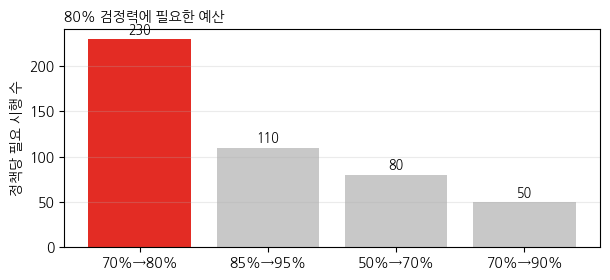

85% → 95%                      110회
50% → 70%                       80회
70% → 90%                       50회


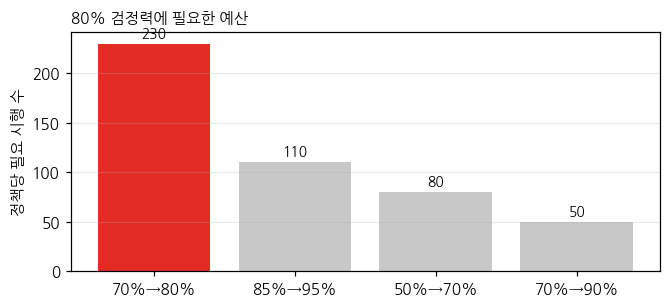

In [4]:
print("80% 검정력에 필요한 시행 수 (정책당, α=0.05 단측)")
print(f"{'검출하려는 차이':<22}{'필요 시행 수':>14}")
print("-" * 36)
need = {}
for pa, pb in [(.70, .80), (.85, .95), (.50, .70), (.70, .90)]:
    for n in range(10, 1201, 10):
        hit = sum(ztest(rng.binomial(n, pa), n, rng.binomial(n, pb), n) < .05 for _ in range(400))
        if hit / 400 >= .80:
            need[(pa, pb)] = n
            print(f"{f'{pa:.0%} → {pb:.0%}':<22}{n:>12}회")
            break
    else:
        print(f"{f'{pa:.0%} → {pb:.0%}':<22}{'1200회로도 부족':>14}")

fig, ax = plt.subplots(figsize=(6.2, 2.9))
lbl = [f"{a:.0%}→{b:.0%}" for a, b in need]
ax.bar(lbl, [need[k] for k in need], color=[RED if v > 150 else GREY for v in need.values()])
for i, v in enumerate(need.values()): ax.text(i, v + 6, str(v), ha="center", fontsize=9)
ax.set_ylabel("정책당 필요 시행 수"); ax.grid(alpha=.25, axis="y")
ax.set_title("80% 검정력에 필요한 예산", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 4. 같은 조건에서 겨루게 하면

여기까지는 두 정책을 각각 따로 돌린다고 가정했다. 그런데 로봇 평가에서 결과를 가르는 가장 큰 요인은 대개 정책이 아니라 **그 회차의 초기 조건**이다 — 물건이 어디 놓였는지, 조명이 어떤지, 그리퍼가 어느 각도로 시작했는지.

두 정책을 **같은 초기 조건**에서 돌리면 그 변동을 상쇄할 수 있다. 짝지은 비교에는 McNemar 검정을 쓴다 — 두 정책의 판정이 **엇갈린 회차만** 센다.

초기 조건이 결과 변동의 얼마를 설명하는지를 $w^2$ 로 놓고 바꿔 가며 본다. 참값은 70% 대 80% 로 고정이다.

w²=25%  n=20: 따로 18% / 같은조건 10%  n=50: 따로 30% / 같은조건 24%  n=100: 따로 49% / 같은조건 50%  n=200: 따로 76% / 같은조건 77%
w²=64%  n=20: 따로 18% / 같은조건 8%  n=50: 따로 29% / 같은조건 34%  n=100: 따로 49% / 같은조건 61%  n=200: 따로 75% / 같은조건 88%
w²=90%  n=20: 따로 19% / 같은조건 7%  n=50: 따로 34% / 같은조건 47%  n=100: 따로 51% / 같은조건 83%  n=200: 따로 76% / 같은조건 99%


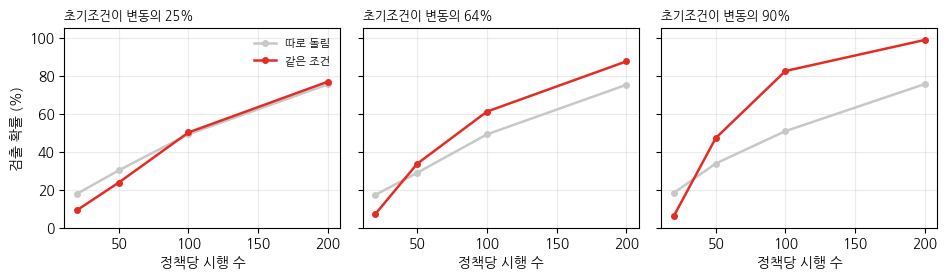

w²=90%  n=20: 따로 19% / 같은조건 7%  n=50: 따로 34% / 같은조건 47%  n=100: 따로 51% / 같은조건 83%  n=200: 따로 76% / 같은조건 99%


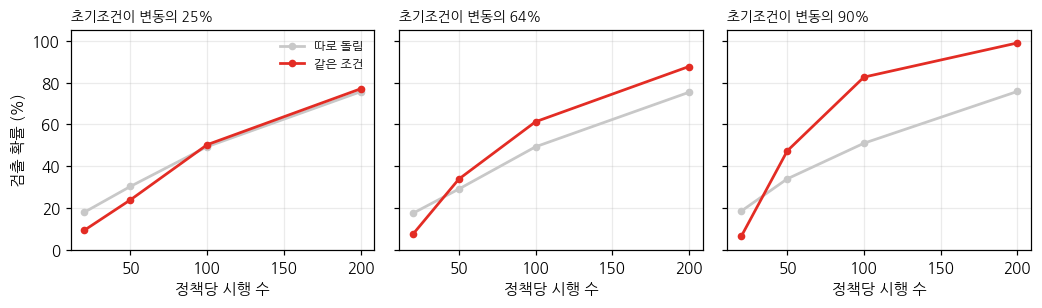

In [5]:
Phi = NormalDist().inv_cdf
def mcnemar(b, c):
    n = b + c
    return 1.0 if n == 0 else sum(comb(n, i) for i in range(c, n + 1)) / 2 ** n

PA, PB = .70, .80; tA, tB = Phi(PA), Phi(PB)
def sim(n, w, trials=2000):
    up = pa = 0; k = sqrt(1 - w * w)
    for _ in range(trials):
        ds = rng.normal(0, 1, n); e1 = rng.normal(0, 1, n); e3 = rng.normal(0, 1, n)
        a = (w * rng.normal(0, 1, n) + k * rng.normal(0, 1, n)) < tA      # 비대응
        b = (w * rng.normal(0, 1, n) + k * rng.normal(0, 1, n)) < tB
        up += ztest(a.sum(), n, b.sum(), n) < .05
        a2 = (w * ds + k * e1) < tA; b2 = (w * ds + k * e3) < tB          # 대응
        up_b = int((a2 & ~b2).sum()); up_c = int((~a2 & b2).sum())
        pa += mcnemar(up_b, up_c) < .05
    return up / trials * 100, pa / trials * 100

fig, axes = plt.subplots(1, 3, figsize=(9.6, 2.9), sharey=True)
Ns = [20, 50, 100, 200]
for ax, w in zip(axes, [0.5, 0.8, 0.95]):
    u = []; p = []
    for n in Ns:
        a, b = sim(n, w); u.append(a); p.append(b)
    ax.plot(Ns, u, "o-", color=GREY, lw=1.8, ms=4, label="따로 돌림")
    ax.plot(Ns, p, "o-", color=RED, lw=1.8, ms=4, label="같은 조건")
    ax.set_title(f"초기조건이 변동의 {w*w:.0%}", fontsize=9, loc="left")
    ax.set_xlabel("정책당 시행 수"); ax.grid(alpha=.25); ax.set_ylim(0, 105)
    print(f"w²={w*w:.0%}  " + "  ".join(f"n={n}: 따로 {a:.0f}% / 같은조건 {b:.0f}%" for n, a, b in zip(Ns, u, p)))
axes[0].set_ylabel("검출 확률 (%)"); axes[0].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## 5. 성공/실패 대신 진행도를 재면

마지막 방법은 검정을 바꾸는 것이 아니라 **측정을 바꾸는** 것이다.

성공/실패는 에피소드당 1비트다. 그런데 우리는 그 에피소드에서 훨씬 많은 것을 봤다 — 물건에 손이 닿았는지, 쥐었는지, 들었는지, 옮기다 놓쳤는지. 이 단계 점수를 쓰면 같은 회차에서 정보가 늘어난다.

두 정책을 진행도 0~1 의 연속값으로 비교한다(t 검정). 성공률은 그 진행도가 1.0 에 닿은 비율이다.

정책당 시행             성공/실패       진행도
----------------------------------
10                    6%       20%
20                   16%       31%
50                   27%       55%
100                  40%       79%
200                  61%       96%


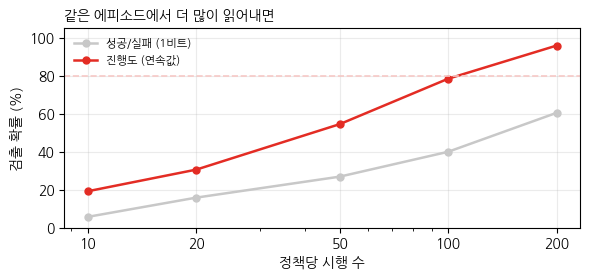

200                  61%       96%


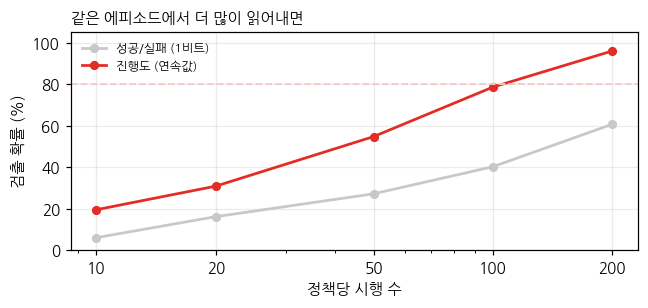

In [6]:
def sim_score(n, trials=2000, gap=.35):
    # 정책 B 가 평균 진행도에서 gap*sigma 만큼 앞선다. 성공 = 진행도 1.0 도달
    bin_hit = cont_hit = 0
    for _ in range(trials):
        sa = np.clip(rng.normal(.55, .30, n), 0, 1)
        sb = np.clip(rng.normal(.55 + gap * .30, .30, n), 0, 1)
        ka = int((sa >= .999).sum()); kb = int((sb >= .999).sum())
        bin_hit += ztest(ka, n, kb, n) < .05
        d = sb.mean() - sa.mean()
        se = sqrt(sa.var(ddof=1) / n + sb.var(ddof=1) / n)
        cont_hit += (1 - .5 * (1 + erf((d / se) / sqrt(2)))) < .05 if se > 0 else 0
    return bin_hit / trials * 100, cont_hit / trials * 100

print(f"{'정책당 시행':<12}{'성공/실패':>12}{'진행도':>10}")
print("-" * 34)
Ns = [10, 20, 50, 100, 200]
bb, cc = [], []
for n in Ns:
    b, c = sim_score(n); bb.append(b); cc.append(c)
    print(f"{n:<12}{b:11.0f}%{c:9.0f}%")

fig, ax = plt.subplots(figsize=(6, 2.9))
ax.plot(Ns, bb, "o-", color=GREY, lw=1.8, ms=5, label="성공/실패 (1비트)")
ax.plot(Ns, cc, "o-", color=RED, lw=1.8, ms=5, label="진행도 (연속값)")
ax.axhline(80, color=PINK, ls="--", lw=1.2)
ax.set_xlabel("정책당 시행 수"); ax.set_ylabel("검출 확률 (%)")
ax.set_xscale("log"); ax.set_xticks(Ns)
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25); ax.set_ylim(0, 105)
ax.set_title("같은 에피소드에서 더 많이 읽어내면", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

### 다음 장으로
다음 장에서는 이렇게 제대로 재고 나면 드러나는 문제를 다룬다. 시연을 아무리 늘려도 넘지 못하는 벽이 있고, 그 벽은 데이터가 아니라 **목적함수**가 만든 것이다.